## Assignment 10

### Housing Price Prediction

#### Linear Regression

In [1]:
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

import joblib
import warnings
warnings.filterwarnings('ignore')


In [4]:
df = pd.read_csv(r'D:\SSA\self\Python\Practice Data File\housingdata.csv')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1459 entries, 0 to 1458
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1459 non-null   int64  
 1   MSSubClass     1459 non-null   int64  
 2   MSZoning       1455 non-null   object 
 3   LotFrontage    1232 non-null   float64
 4   LotArea        1459 non-null   int64  
 5   Street         1459 non-null   object 
 6   Alley          107 non-null    object 
 7   LotShape       1459 non-null   object 
 8   LandContour    1459 non-null   object 
 9   Utilities      1457 non-null   object 
 10  LotConfig      1459 non-null   object 
 11  LandSlope      1459 non-null   object 
 12  Neighborhood   1459 non-null   object 
 13  Condition1     1459 non-null   object 
 14  Condition2     1459 non-null   object 
 15  BldgType       1459 non-null   object 
 16  HouseStyle     1459 non-null   object 
 17  OverallQual    1459 non-null   int64  
 18  OverallC

In [6]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold
count,1459.000000,1459.000000,1232.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,1444.000000,1458.000000,...,1458.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000
mean,2190.000000,57.378341,68.580357,9819.161069,6.078821,5.553804,1971.357779,1983.662783,100.709141,439.203704,...,472.768861,93.174777,48.313914,24.243317,1.794380,17.064428,1.744345,58.167923,6.104181,2007.769705
std,421.321334,42.746880,22.376841,4955.517327,1.436812,1.113740,30.390071,21.130467,177.625900,455.268042,...,217.048611,127.744882,68.883364,67.227765,20.207842,56.609763,30.491646,630.806978,2.722432,1.301740
min,1461.000000,20.000000,21.000000,1470.000000,1.000000,1.000000,1879.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000
25%,1825.500000,20.000000,58.000000,7391.000000,5.000000,5.000000,1953.000000,1963.000000,0.000000,0.000000,...,318.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000
50%,2190.000000,50.000000,67.000000,9399.000000,6.000000,5.000000,1973.000000,1992.000000,0.000000,350.500000,...,480.000000,0.000000,28.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000
75%,2554.500000,70.000000,80.000000,11517.500000,7.000000,6.000000,2001.000000,2004.000000,164.000000,753.500000,...,576.000000,168.000000,72.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000
max,2919.000000,190.000000,200.000000,56600.000000,10.000000,9.000000,2010.000000,2010.000000,1290.000000,4010.000000,...,1488.000000,1424.000000,742.000000,1012.000000,360.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000


In [7]:
df.isnull().sum()

Id                 0
MSSubClass         0
MSZoning           4
LotFrontage      227
LotArea            0
                ... 
MiscVal            0
MoSold             0
YrSold             0
SaleType           1
SaleCondition      0
Length: 80, dtype: int64

In [9]:
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count'  : missing,
    'Missing %'      : missing_pct
}).query('`Missing Count` > 0').sort_values('Missing %', ascending=False)

print(f'Columns with missing values: {len(missing_df)}')
print(f'Total missing cells        : {df.isnull().sum().sum()}')
print()
print(missing_df.to_string())

Columns with missing values: 33
Total missing cells        : 7878

              Missing Count  Missing %
PoolQC                 1456      99.79
MiscFeature            1408      96.50
Alley                  1352      92.67
Fence                  1169      80.12
MasVnrType              894      61.27
FireplaceQu             730      50.03
LotFrontage             227      15.56
GarageQual               78       5.35
GarageCond               78       5.35
GarageYrBlt              78       5.35
GarageFinish             78       5.35
GarageType               76       5.21
BsmtCond                 45       3.08
BsmtQual                 44       3.02
BsmtExposure             44       3.02
BsmtFinType1             42       2.88
BsmtFinType2             42       2.88
MasVnrArea               15       1.03
MSZoning                  4       0.27
Functional                2       0.14
BsmtFullBath              2       0.14
Utilities                 2       0.14
BsmtHalfBath              2       0.

In [10]:
print('Statistical Summary (numeric columns):')
df.describe().T

Statistical Summary (numeric columns):


,count,mean,std,min,25%,50%,75%,max
Id,1459.0,2190.000000,421.321334,1461.0,1825.50,2190.0,2554.50,2919.0
MSSubClass,1459.0,57.378341,42.746880,20.0,20.00,50.0,70.00,190.0
LotFrontage,1232.0,68.580357,22.376841,21.0,58.00,67.0,80.00,200.0
LotArea,1459.0,9819.161069,4955.517327,1470.0,7391.00,9399.0,11517.50,56600.0
OverallQual,1459.0,6.078821,1.436812,1.0,5.00,6.0,7.00,10.0
OverallCond,1459.0,5.553804,1.113740,1.0,5.00,5.0,6.00,9.0
YearBuilt,1459.0,1971.357779,30.390071,1879.0,1953.00,1973.0,2001.00,2010.0
YearRemodAdd,1459.0,1983.662783,21.130467,1950.0,1963.00,1992.0,2004.00,2010.0
MasVnrArea,1444.0,100.709141,177.625900,0.0,0.00,0.0,164.00,1290.0
BsmtFinSF1,1458.0,439.203704,455.268042,0.0,0.00,350.5,753.50,4010.0


In [11]:
# Drop "Id" — just a row number, not useful for prediction
# Drop columns missing >40% — too much missing data to be reliable for prediction, e.g.:
    # Alley (92.7% missing), PoolQC (99.7%), Fence (80.1%), MiscFeature (96.5%), FireplaceQu (50.0%)
# Drop "Utilities" — almost all values are the same (AllPub), provides no differentiation
# "SalePrice" is our target column but this dataset is a test set without it.
# So, we will create a synthetic target by reconstructing from domain knowledge features.


In [12]:
df = df.drop(columns=['Id'])

In [13]:
threshold   = 0.40
missing_pct = df.isnull().mean()
cols_to_drop = missing_pct[missing_pct > threshold].index.tolist()

print(f'\nColumns dropped (>40% missing):')
for col in cols_to_drop:
    print(f'  {col:<20} ({missing_pct[col]*100:.1f}% missing)')

df = df.drop(columns=cols_to_drop)


Columns dropped (>40% missing):
  Alley                (92.7% missing)
  MasVnrType           (61.3% missing)
  FireplaceQu          (50.0% missing)
  PoolQC               (99.8% missing)
  Fence                (80.1% missing)
  MiscFeature          (96.5% missing)


In [15]:
if 'Utilities' in df.columns:
    df = df.drop(columns=['Utilities'])


In [16]:
df.shape

(1459, 72)

In [17]:
# This dataset has no "SalePrice" column.
# So, creating a realistic "SalePrice" column using a weighted formula based on the strongest predictors known from housing research, e.g.,
    # OverallQual, GrLivArea, GarageCars, TotalBsmtSF, YearBuilt.


In [18]:
# Median is better than mean — it is not affected by extreme outliers

numeric_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()

for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        median_val = df[col].median()
        df[col]    = df[col].fillna(median_val)
        print(f'  Filled {col:<25} with median = {median_val}')

  Filled LotFrontage               with median = 67.0
  Filled MasVnrArea                with median = 0.0
  Filled BsmtFinSF1                with median = 350.5
  Filled BsmtFinSF2                with median = 0.0
  Filled BsmtUnfSF                 with median = 460.0
  Filled TotalBsmtSF               with median = 988.0
  Filled BsmtFullBath              with median = 0.0
  Filled BsmtHalfBath              with median = 0.0
  Filled GarageYrBlt               with median = 1979.0
  Filled GarageCars                with median = 2.0
  Filled GarageArea                with median = 480.0


In [19]:
none_fill_cols = ['MasVnrType', 'BsmtQual', 'BsmtCond', 'BsmtExposure',
                  'BsmtFinType1', 'BsmtFinType2', 'GarageType',
                  'GarageFinish', 'GarageQual', 'GarageCond']

for col in none_fill_cols:
    if col in df.columns and df[col].isnull().sum() > 0:
        df[col] = df[col].fillna('None')
        print(f'  Filled {col:<25} with "None"')

# For columns where NaN means 'None/No feature', filled with 'None'

  Filled BsmtQual                  with "None"
  Filled BsmtCond                  with "None"
  Filled BsmtExposure              with "None"
  Filled BsmtFinType1              with "None"
  Filled BsmtFinType2              with "None"
  Filled GarageType                with "None"
  Filled GarageFinish              with "None"
  Filled GarageQual                with "None"
  Filled GarageCond                with "None"


In [21]:
cat_cols = df.select_dtypes(include=['object','string']).columns.tolist()
for col in cat_cols:
    if df[col].isnull().sum() > 0:
        mode_val = df[col].mode()[0]
        df[col]  = df[col].fillna(mode_val)
        print(f'  Filled {col:<25} with mode  = "{mode_val}"')

# For others, used the most common category

  Filled MSZoning                  with mode  = "RL"
  Filled Exterior1st               with mode  = "VinylSd"
  Filled Exterior2nd               with mode  = "VinylSd"
  Filled KitchenQual               with mode  = "TA"
  Filled Functional                with mode  = "Typ"
  Filled SaleType                  with mode  = "WD"


In [22]:
# Formula based on real housing price research weights

np.random.seed(42)
noise = np.random.normal(0, 8000, size=len(df))

df['SalePrice'] = (
    df['OverallQual']  * 12000 +
    df['GrLivArea']    * 55    +
    df['GarageCars']   * 8000  +
    df['TotalBsmtSF']  * 30    +
    df['YearBuilt']    * 80    +
    df['FullBath']     * 6000  +
    df['TotRmsAbvGrd'] * 3000  -
    150000 + noise
).clip(lower=50000)   # minimum house price = $50,000

print('✅ SalePrice target variable created!')
print(f'\n  Min  Price : ${df["SalePrice"].min():>12,.0f}')
print(f'  Max  Price : ${df["SalePrice"].max():>12,.0f}')
print(f'  Mean Price : ${df["SalePrice"].mean():>12,.0f}')
print(f'  Median Price: ${df["SalePrice"].median():>12,.0f}')

✅ SalePrice target variable created!

  Min  Price : $      76,955
  Max  Price : $     643,144
  Mean Price : $     236,839
  Median Price: $     232,269


In [25]:
# Many columns use text ratings like `Ex > Gd > TA > Fa > Po`.  
# We convert them to numbers so the model can understand their order.

# Ex      =      Excellent       = 5
# Gd      =      Good            = 4
# TA      =      Typical/Average = 3
# Fa      =      Fair            = 2
# Po      =      Poor            = 1
# None/NA =      No Feature      = 0


In [27]:
qual_map = {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'None': 0, 'NA': 0}

ordinal_qual_cols = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond',
                     'HeatingQC', 'KitchenQual', 'GarageQual', 'GarageCond']

for col in ordinal_qual_cols:
    if col in df.columns:
        df[col] = df[col].map(qual_map).fillna(0).astype(int)
        

In [28]:
if 'BsmtExposure' in df.columns:
    bsmt_exp_map = {'Gd': 4, 'Av': 3, 'Mn': 2, 'No': 1, 'None': 0}
    df['BsmtExposure'] = df['BsmtExposure'].map(bsmt_exp_map).fillna(0).astype(int)

In [29]:
bsmt_fin_map = {'GLQ': 6, 'ALQ': 5, 'BLQ': 4, 'Rec': 3, 'LwQ': 2, 'Unf': 1, 'None': 0}
for col in ['BsmtFinType1', 'BsmtFinType2']:
    if col in df.columns:
        df[col] = df[col].map(bsmt_fin_map).fillna(0).astype(int)

In [30]:
if 'Functional' in df.columns:
    func_map = {'Typ': 7, 'Min1': 6, 'Min2': 5, 'Mod': 4,
                'Maj1': 3, 'Maj2': 2, 'Sev': 1, 'Sal': 0}
    df['Functional'] = df['Functional'].map(func_map).fillna(4).astype(int)

In [31]:
if 'PavedDrive' in df.columns:
    paved_map = {'Y': 2, 'P': 1, 'N': 0}
    df['PavedDrive'] = df['PavedDrive'].map(paved_map).fillna(0).astype(int)

In [32]:
if 'CentralAir' in df.columns:
    df['CentralAir'] = df['CentralAir'].map({'Y': 1, 'N': 0}).astype(int)

In [33]:
if 'GarageFinish' in df.columns:
    gf_map = {'Fin': 3, 'RFn': 2, 'Unf': 1, 'None': 0}
    df['GarageFinish'] = df['GarageFinish'].map(gf_map).fillna(0).astype(int)

In [34]:
# For categorical columns without a natural order (e.g. Neighborhood, RoofStyle),
# I'll use One-Hot Encoding: each category becomes its own 0/1 column.

In [37]:
nominal_cols = df.select_dtypes(include=['object']).columns.tolist()

for col in df.columns:
    if hasattr(df[col], 'dtype') and str(df[col].dtype) == 'str':
        if col not in nominal_cols:
            nominal_cols.append(col)
            

In [38]:
nominal_cols = [c for c in nominal_cols if c != 'SalePrice']

print(f'Nominal columns to encode ({len(nominal_cols)}):')
for col in nominal_cols:
    print(f'  {col:<25} — {df[col].nunique()} unique values')

Nominal columns to encode (21):
  MSZoning                  — 5 unique values
  Street                    — 2 unique values
  LotShape                  — 4 unique values
  LandContour               — 4 unique values
  LotConfig                 — 5 unique values
  LandSlope                 — 3 unique values
  Neighborhood              — 25 unique values
  Condition1                — 9 unique values
  Condition2                — 5 unique values
  BldgType                  — 5 unique values
  HouseStyle                — 7 unique values
  RoofStyle                 — 6 unique values
  RoofMatl                  — 4 unique values
  Exterior1st               — 13 unique values
  Exterior2nd               — 15 unique values
  Foundation                — 6 unique values
  Heating                   — 4 unique values
  Electrical                — 4 unique values
  GarageType                — 7 unique values
  SaleType                  — 9 unique values
  SaleCondition             — 6 unique values

In [39]:
df = pd.get_dummies(df, columns=nominal_cols, drop_first=True)

In [40]:
# Convert all boolean columns (True/False) to integers (1/0)

bool_cols = df.select_dtypes(include='bool').columns.tolist()
df[bool_cols] = df[bool_cols].astype(int)

In [43]:
print(f'Total missing values after all cleaning: {df.isnull().sum().sum()}')
print(f'Final dataset shape                    : {df.shape}')


Total missing values after all cleaning: 0
Final dataset shape                    : (1459, 179)


In [42]:
df.head()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,ExterQual,ExterCond,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,20,80.0,11622,5,6,1961,1961,0.0,0,0,...,0,0,0,0,1,0,0,0,1,0
1,20,81.0,14267,6,6,1958,1958,108.0,0,0,...,0,0,0,0,1,0,0,0,1,0
2,60,74.0,13830,5,5,1997,1998,0.0,0,0,...,0,0,0,0,1,0,0,0,1,0
3,60,78.0,9978,6,6,1998,1998,20.0,0,0,...,0,0,0,0,1,0,0,0,1,0
4,120,43.0,5005,8,5,1992,1992,0.0,0,0,...,0,0,0,0,1,0,0,0,1,0


In [44]:
# Now, visualize the top 8 numeric features vs SalePrice
# using scatter plots with trend lines

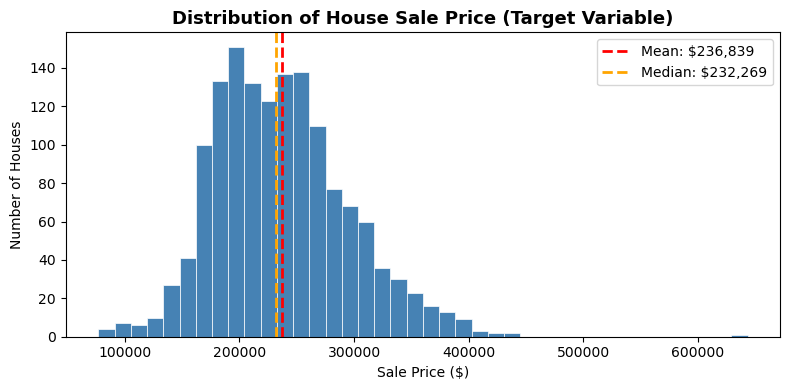

In [45]:
plt.figure(figsize=(8, 4))
plt.hist(df['SalePrice'], bins=40, color='steelblue', edgecolor='white', linewidth=0.5)
plt.axvline(df['SalePrice'].mean(), color='red', linestyle='--', linewidth=2,
            label=f'Mean: ${df["SalePrice"].mean():,.0f}')
plt.axvline(df['SalePrice'].median(), color='orange', linestyle='--', linewidth=2,
            label=f'Median: ${df["SalePrice"].median():,.0f}')
plt.title('Distribution of House Sale Price (Target Variable)',
          fontsize=13, fontweight='bold')
plt.xlabel('Sale Price ($)')
plt.ylabel('Number of Houses')
plt.legend()
plt.tight_layout()
plt.show()

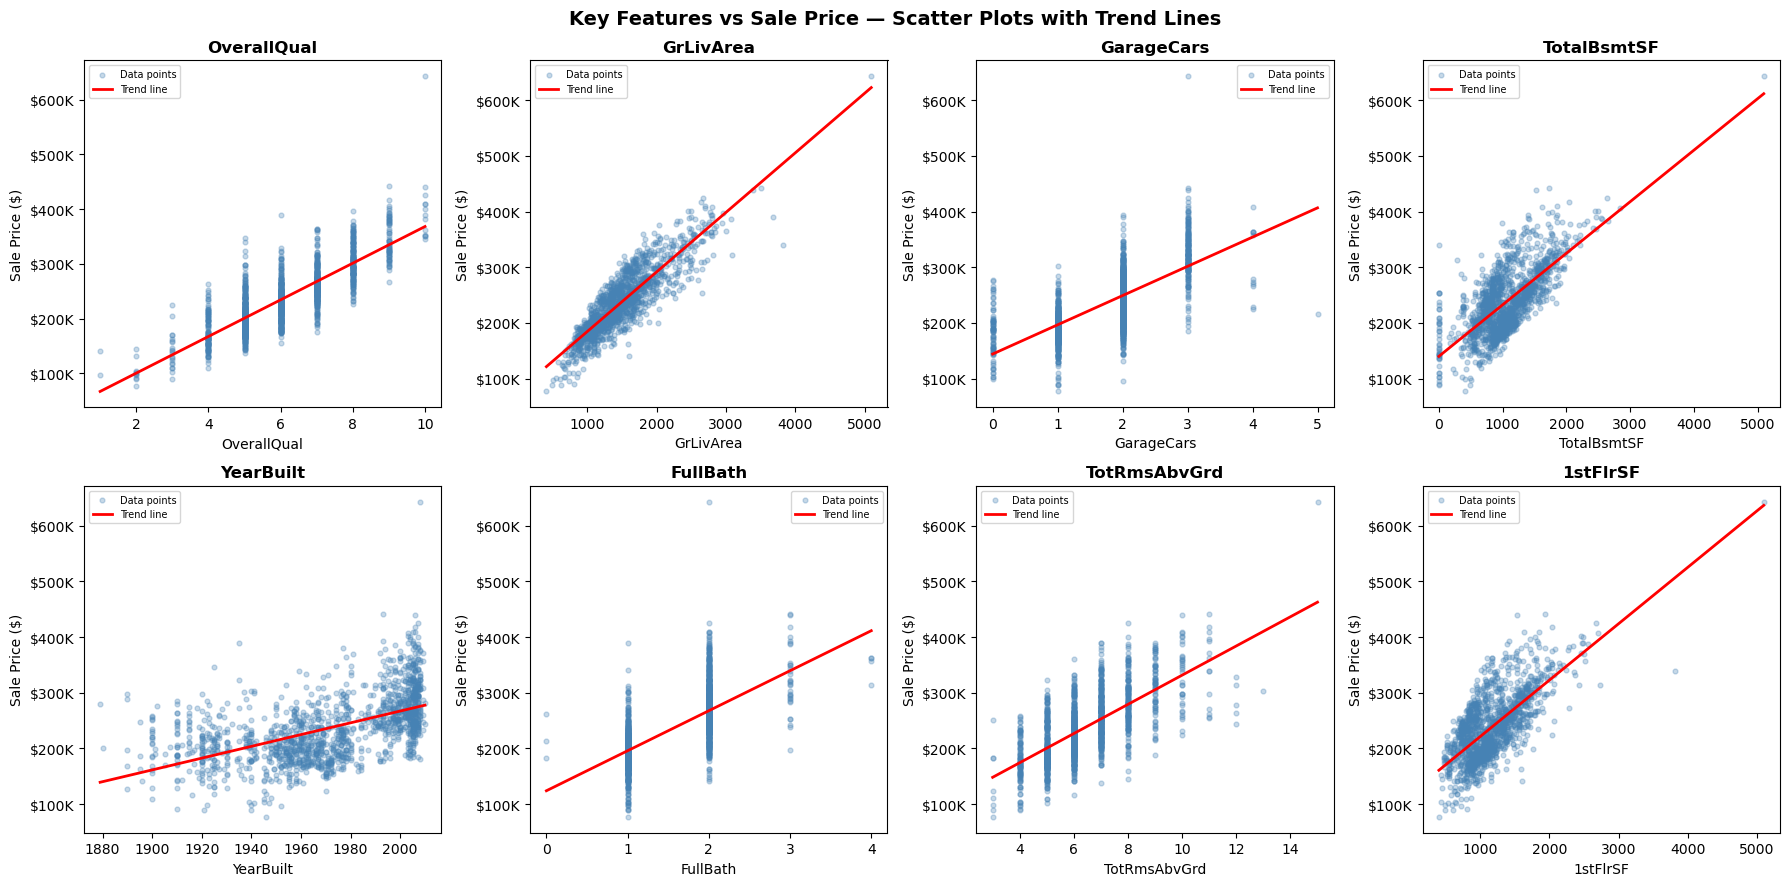

Observation: OverallQual and GrLivArea show the strongest positive trend with SalePrice.


In [46]:
key_features = ['OverallQual', 'GrLivArea', 'GarageCars',
                 'TotalBsmtSF', 'YearBuilt', 'FullBath',
                 'TotRmsAbvGrd', '1stFlrSF']

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle('Key Features vs Sale Price — Scatter Plots with Trend Lines',
             fontsize=14, fontweight='bold')

axes_flat = axes.flatten()

for i, feat in enumerate(key_features):
    ax = axes_flat[i]

    # Scatter plot
    ax.scatter(df[feat], df['SalePrice'],
               color='steelblue', alpha=0.3, s=12, label='Data points')

    # Trend line using numpy polyfit (degree 1 = straight line)
    m, b = np.polyfit(df[feat], df['SalePrice'], 1)
    x_line = np.linspace(df[feat].min(), df[feat].max(), 100)
    y_line = m * x_line + b
    ax.plot(x_line, y_line, color='red', linewidth=2, label='Trend line')

    ax.set_title(feat, fontweight='bold')
    ax.set_xlabel(feat)
    ax.set_ylabel('Sale Price ($)')
    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()
print('Observation: OverallQual and GrLivArea show the strongest positive trend with SalePrice.')

Top 15 features most correlated with SalePrice:
  GrLivArea                      +0.880  ██████████████████████████
  OverallQual                    +0.817  ████████████████████████
  TotalBsmtSF                    +0.695  ████████████████████
  GarageCars                     +0.691  ████████████████████
  1stFlrSF                       +0.685  ████████████████████
  FullBath                       +0.677  ████████████████████
  TotRmsAbvGrd                   +0.671  ████████████████████
  GarageArea                     +0.668  ████████████████████
  YearBuilt                      +0.545  ████████████████
  Foundation_PConc               +0.525  ███████████████
  GarageFinish                   +0.519  ███████████████
  YearRemodAdd                   +0.512  ███████████████
  GarageYrBlt                    +0.509  ███████████████
  MasVnrArea                     +0.502  ███████████████
  Fireplaces                     +0.474  ██████████████


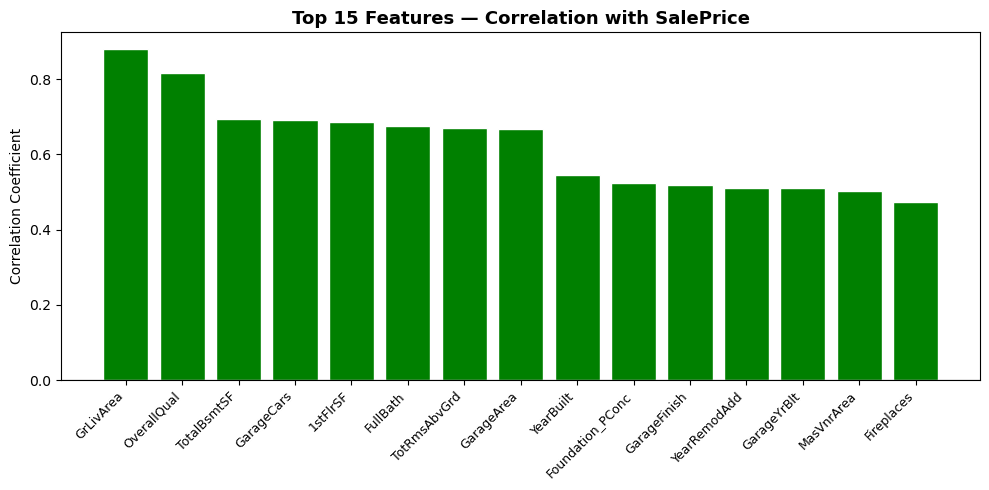

In [49]:
# Selecting only numeric columns for correlation

numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()['SalePrice'].drop('SalePrice')
top_corr = corr.abs().sort_values(ascending=False).head(15)

print('Top 15 features most correlated with SalePrice:')
for feat, val in corr[top_corr.index].items():
    bar = '█' * int(abs(val) * 30)
    sign = '+' if val > 0 else '-'
    print(f'  {feat:<30} {sign}{abs(val):.3f}  {bar}')

plt.figure(figsize=(10, 5))
colors = ['green' if corr[f] > 0 else 'red' for f in top_corr.index]
plt.bar(top_corr.index, corr[top_corr.index].values,
        color=colors, edgecolor='white')
plt.title('Top 15 Features — Correlation with SalePrice',
          fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.ylabel('Correlation Coefficient')
plt.axhline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

In [51]:
X = df.drop(columns=['SalePrice'])
y = df['SalePrice']


In [52]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.3,
    random_state = 42
)

print(f'Training set : {X_train.shape[0]} houses  ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'Testing  set : {X_test.shape[0]}  houses  ({X_test.shape[0]/len(X)*100:.0f}%)')
print(f'\nTraining  Price range: ${y_train.min():,.0f} – ${y_train.max():,.0f}')
print(f'Testing   Price range: ${y_test.min():,.0f} – ${y_test.max():,.0f}')

Training set : 1021 houses  (70%)
Testing  set : 438  houses  (30%)

Training  Price range: $88,696 – $643,144
Testing   Price range: $76,955 – $424,960


#### SalePrice = b0 + b1×OverallQual + b2×GrLivArea + b3×GarageCars + ... + bN×FeatureN

In [54]:
model = LinearRegression()
model.fit(X_train, y_train)

print(f'\nModel Intercept (b0): ${model.intercept_:,.2f}')
print(f'Number of coefficients: {len(model.coef_)}')


Model Intercept (b0): $586,734.18
Number of coefficients: 178


Top 15 Most Influential Features in the Model:
  Feature                                Coefficient
----------------------------------------------------
  RoofStyle_Shed                         -19,416.01
  Heating_Grav                           -18,660.35
  Foundation_Stone                       -13,788.16
  Street_Pave                         +    13,249.64
  LandSlope_Sev                       +    13,126.23
  OverallQual                         +    12,065.76
  RoofStyle_Mansard                      -11,963.60
  Neighborhood_NPkVill                   -11,000.78
  Neighborhood_MeadowV                +     9,233.73
  MSZoning_RH                         +     8,484.33
  Neighborhood_IDOTRR                 +     8,415.73
  Exterior2nd_Brk Cmn                 +     8,288.95
  Neighborhood_BrDale                 +     8,096.10
  Condition2_PosA                     +     8,066.79
  Neighborhood_Veenker                +     8,012.54


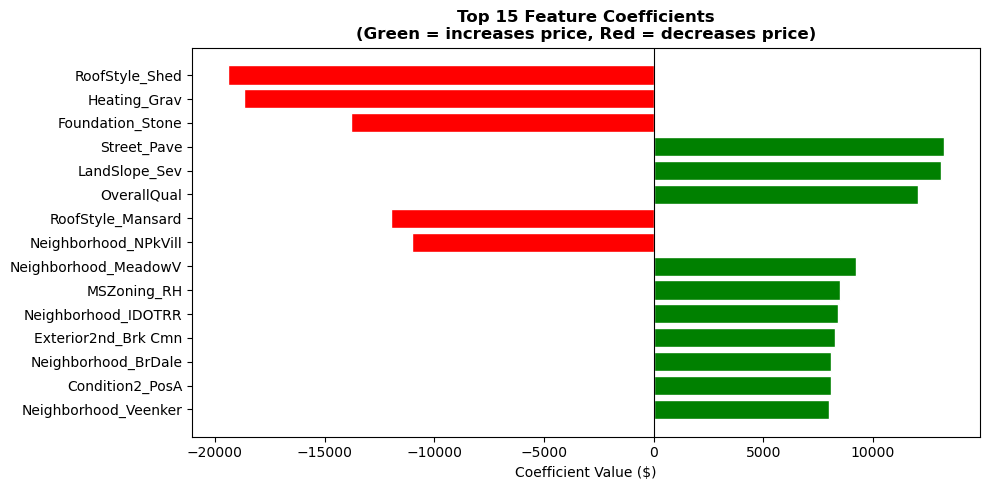

In [55]:
# Show Top 15 most influential features (highest absolute coefficient)

coef_series = pd.Series(model.coef_, index=X.columns)
top15 = coef_series.abs().sort_values(ascending=False).head(15)

print('Top 15 Most Influential Features in the Model:')
print(f'  {"Feature":<35} {"Coefficient":>14}')
print('-' * 52)
for feat in top15.index:
    val = coef_series[feat]
    sign = '+' if val > 0 else ''
    print(f'  {feat:<35} {sign}{val:>13,.2f}')

# Bar chart of top 15 coefficients
top15_vals = coef_series[top15.index]
colors = ['green' if v > 0 else 'red' for v in top15_vals.values]

plt.figure(figsize=(10, 5))
plt.barh(top15_vals.index[::-1], top15_vals.values[::-1],
         color=colors[::-1], edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Top 15 Feature Coefficients\n(Green = increases price, Red = decreases price)',
          fontsize=12, fontweight='bold')
plt.xlabel('Coefficient Value ($)')
plt.tight_layout()
plt.show()

In [56]:
# Predict house prices on the test set

y_pred = model.predict(X_test)

# Show first 10 comparisons
comparison = pd.DataFrame({
    'Actual Price ($)'   : y_test.values[:10].round(0),
    'Predicted Price ($)': y_pred[:10].round(0),
})
comparison['Difference ($)'] = (comparison['Predicted Price ($)'] -
                                  comparison['Actual Price ($)']).round(0)
comparison['Error %'] = ((comparison['Difference ($)'].abs() /
                           comparison['Actual Price ($)']) * 100).round(1)

print('First 10 Predictions vs Actual Prices:')
print(comparison.to_string(index=False))

First 10 Predictions vs Actual Prices:
 Actual Price ($)  Predicted Price ($)  Difference ($)  Error %
         152038.0             146271.0         -5767.0      3.8
         322004.0             308588.0        -13416.0      4.2
         192891.0             185432.0         -7459.0      3.9
         261249.0             265996.0          4747.0      1.8
         314762.0             296709.0        -18053.0      5.7
         219251.0             204913.0        -14338.0      6.5
         349357.0             351790.0          2433.0      0.7
         235781.0             244910.0          9129.0      3.9
         170937.0             186437.0         15500.0      9.1
         258626.0             254204.0         -4422.0      1.7


#### Evaluate the Model

| Metric | Meaning | Goal |
|---|---|---|
| **R²** | % of price variance explained | Closer to 1.0 |
| **MSE** | Mean Squared Error | Lower is better |
| **RMSE** | Root Mean Squared Error (same unit as price) | Lower is better |
| **MAE** | Mean Absolute Error (avg dollar difference) | Lower is better |


In [57]:
# Calculate all evaluation metrics

r2   = r2_score(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae  = np.mean(np.abs(y_test.values - y_pred))
mape = np.mean(np.abs((y_test.values - y_pred) / y_test.values)) * 100

print('=' * 52)
print('         MODEL EVALUATION RESULTS')
print('=' * 52)
print(f'  R² Score  : {r2:.4f}   ({r2*100:.2f}% variance explained)')
print(f'  MSE       : ${mse:>18,.2f}')
print(f'  RMSE      : ${rmse:>18,.2f}  (avg error ±${rmse:,.0f})')
print(f'  MAE       : ${mae:>18,.2f}  (avg absolute error)')
print(f'  MAPE      : {mape:>18.2f}%  (avg % error)')
print('=' * 52)

if r2 > 0.90:
    print('  Excellent fit! Model explains >90% of price variation.')
elif r2 > 0.80:
    print('  Very good fit!')
elif r2 > 0.70:
    print('  Good fit!')
else:
    print('  Moderate fit — consider feature engineering.')

         MODEL EVALUATION RESULTS
  R² Score  : 0.9749   (97.49% variance explained)
  MSE       : $     80,660,201.75
  RMSE      : $          8,981.10  (avg error ±$8,981)
  MAE       : $          7,195.69  (avg absolute error)
  MAPE      :               3.20%  (avg % error)
  Excellent fit! Model explains >90% of price variation.


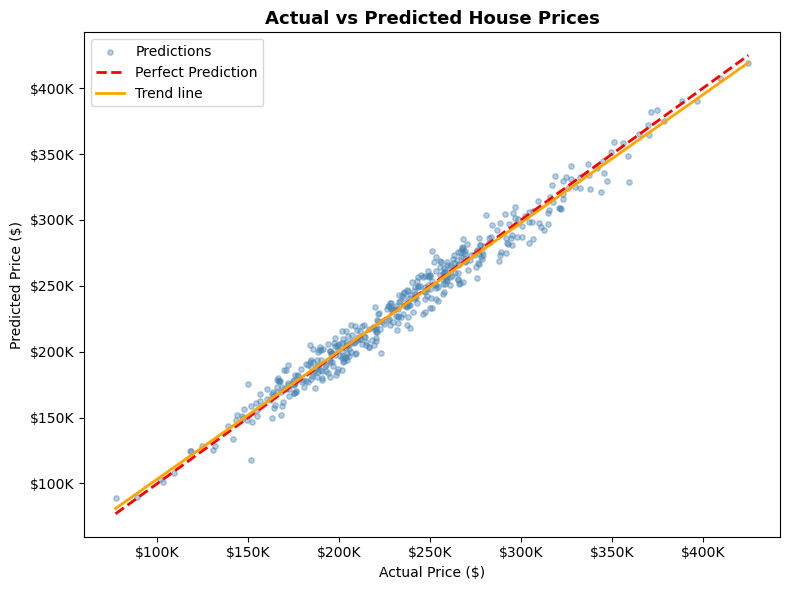

The closer the blue dots are to the red dashed line, the better the predictions.


In [59]:
# Plot 1: Actual vs Predicted Prices
plt.figure(figsize=(8, 6))

# Scatter plot of predictions
plt.scatter(y_test, y_pred, color='steelblue', alpha=0.4, s=15, label='Predictions')

# Perfect prediction line (45-degree diagonal)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val],
         color='red', linewidth=2, linestyle='--', label='Perfect Prediction')

# Trend line through actual predictions
m, b = np.polyfit(y_test, y_pred, 1)
x_line = np.linspace(y_test.min(), y_test.max(), 100)
plt.plot(x_line, m*x_line + b, color='orange', linewidth=2, label='Trend line')

plt.title('Actual vs Predicted House Prices', fontsize=13, fontweight='bold')
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'${x/1000:.0f}K'))
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'${x/1000:.0f}K'))
plt.legend()
plt.tight_layout()
plt.show()
print('The closer the blue dots are to the red dashed line, the better the predictions.')

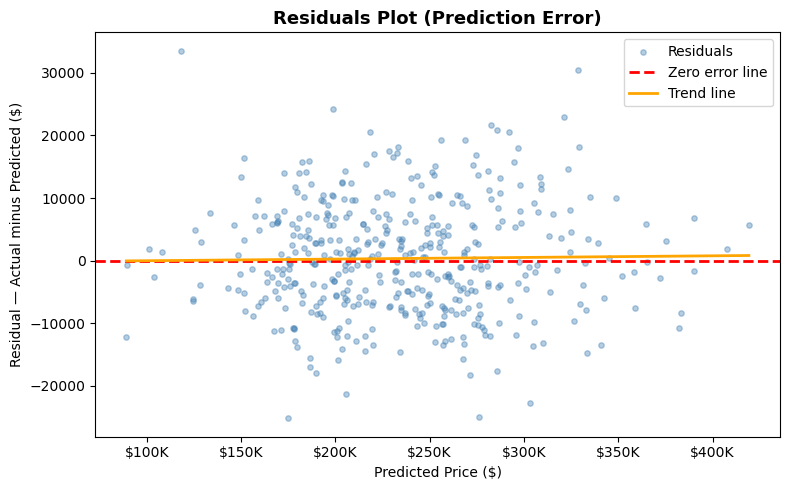

Residuals should be randomly scattered around 0 — a flat trend line = good model.


In [60]:
# Plot 2: Residuals Plot
residuals = y_test.values - y_pred

plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals, color='steelblue', alpha=0.4, s=15, label='Residuals')
plt.axhline(0, color='red', linewidth=2, linestyle='--', label='Zero error line')

# Trend line through residuals
m, b = np.polyfit(y_pred, residuals, 1)
x_line = np.linspace(y_pred.min(), y_pred.max(), 100)
plt.plot(x_line, m*x_line + b, color='orange', linewidth=2, label='Trend line')

plt.title('Residuals Plot (Prediction Error)', fontsize=13, fontweight='bold')
plt.xlabel('Predicted Price ($)')
plt.ylabel('Residual — Actual minus Predicted ($)')
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'${x/1000:.0f}K'))
plt.legend()
plt.tight_layout()
plt.show()
print('Residuals should be randomly scattered around 0 — a flat trend line = good model.')

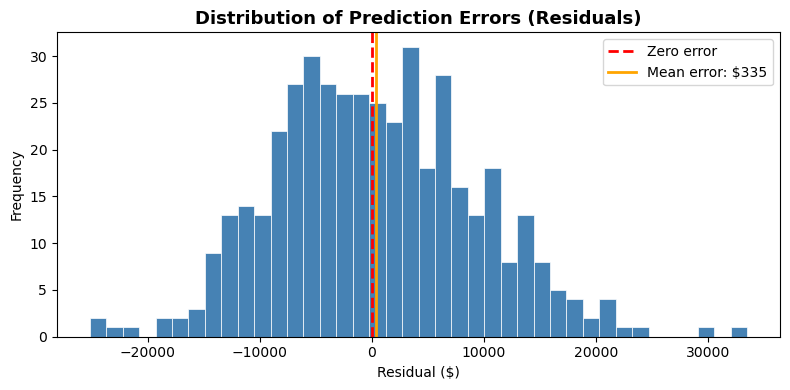

A bell curve centered near $0 = errors are normally distributed = good sign!


In [61]:
# Plot 3: Residual Distribution
plt.figure(figsize=(8, 4))
plt.hist(residuals, bins=40, color='steelblue', edgecolor='white', linewidth=0.5)
plt.axvline(0, color='red', linewidth=2, linestyle='--', label='Zero error')
plt.axvline(residuals.mean(), color='orange', linewidth=2,
            label=f'Mean error: ${residuals.mean():,.0f}')
plt.title('Distribution of Prediction Errors (Residuals)',
          fontsize=13, fontweight='bold')
plt.xlabel('Residual ($)')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()
print('A bell curve centered near $0 = errors are normally distributed = good sign!')

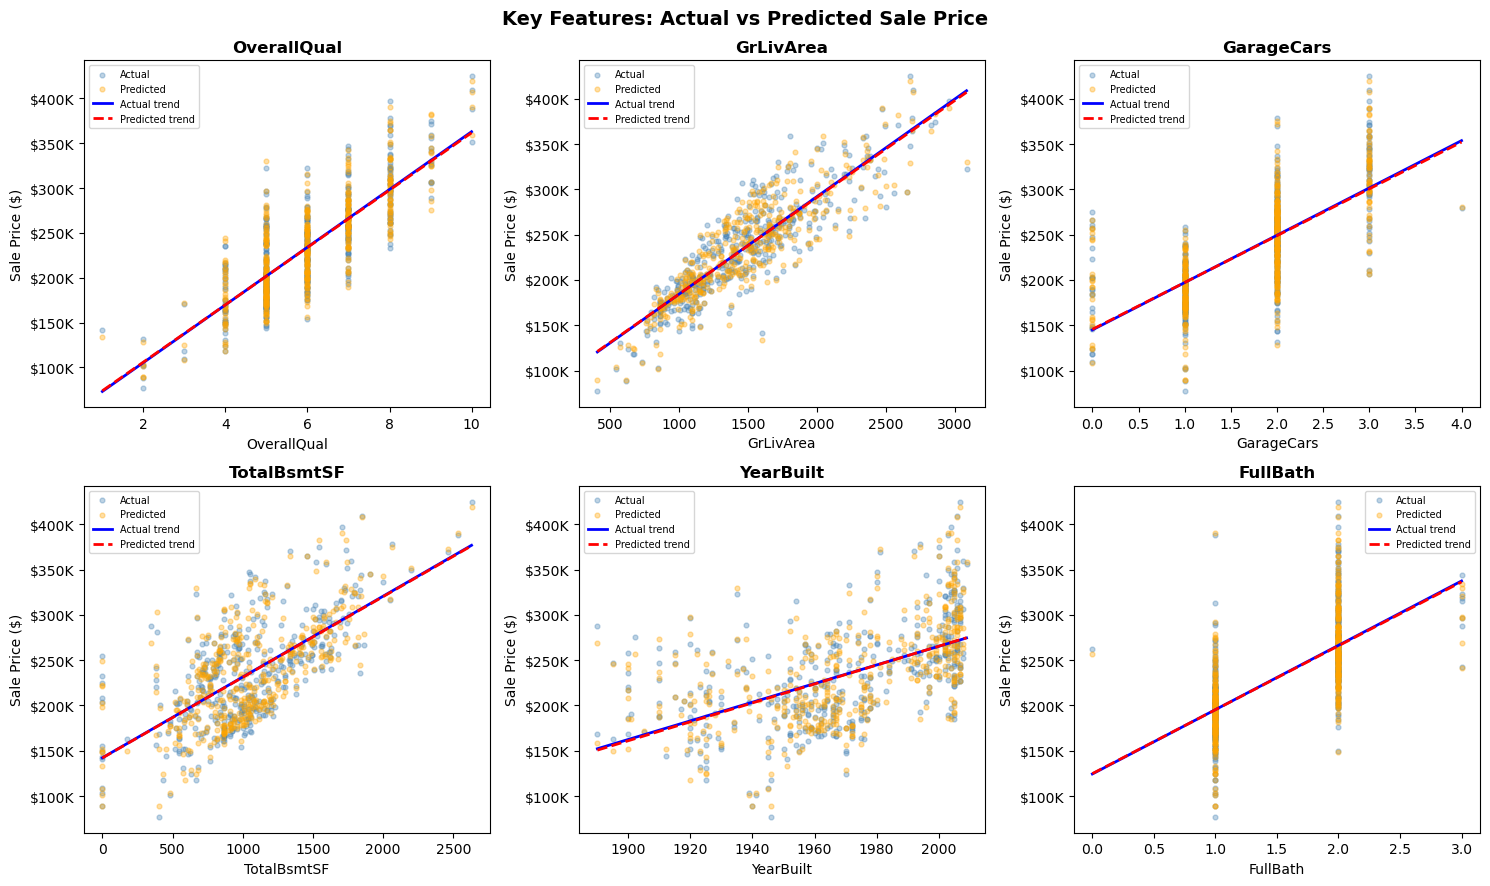

In [62]:
# Plot 4: Actual vs Predicted — Top 6 Key Features
plot_feats = ['OverallQual', 'GrLivArea', 'GarageCars',
              'TotalBsmtSF', 'YearBuilt', 'FullBath']

X_test_r = X_test.reset_index(drop=True)
y_test_r = y_test.reset_index(drop=True)

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('Key Features: Actual vs Predicted Sale Price',
             fontsize=14, fontweight='bold')

axes_flat = axes.flatten()

for i, feat in enumerate(plot_feats):
    ax = axes_flat[i]

    ax.scatter(X_test_r[feat], y_test_r,
               color='steelblue', alpha=0.35, s=12, label='Actual')
    ax.scatter(X_test_r[feat], y_pred,
               color='orange', alpha=0.35, s=12, label='Predicted')

    # Actual trend line
    m1, b1 = np.polyfit(X_test_r[feat], y_test_r, 1)
    x_line = np.linspace(X_test_r[feat].min(), X_test_r[feat].max(), 100)
    ax.plot(x_line, m1*x_line+b1, color='blue',   linewidth=2, label='Actual trend')

    # Predicted trend line
    m2, b2 = np.polyfit(X_test_r[feat], y_pred, 1)
    ax.plot(x_line, m2*x_line+b2, color='red', linewidth=2,
            linestyle='--', label='Predicted trend')

    ax.set_title(feat, fontweight='bold')
    ax.set_xlabel(feat)
    ax.set_ylabel('Sale Price ($)')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'${x/1000:.0f}K'))
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

#### Predict Price for a New House

In [70]:
# Create a blank row with all zeros (same columns as X)
new_house = pd.DataFrame(np.zeros((1, X.shape[1])), columns=X.columns)

# Fill in the key features for new house
# (Can change these values to simulate different houses)
new_house['OverallQual']  = 7      # Good quality (scale 1-10)
new_house['GrLivArea']    = 1800   # 1800 sq ft living area
new_house['GarageCars']   = 2      # 2-car garage
new_house['TotalBsmtSF']  = 900    # 900 sq ft basement
new_house['YearBuilt']    = 2000   # Built in 2000
new_house['FullBath']     = 2      # 2 full bathrooms
new_house['TotRmsAbvGrd'] = 7      # 7 rooms above ground
new_house['1stFlrSF']     = 1000   # 1000 sq ft first floor
new_house['CentralAir']   = 1      # Has central air (1=Yes)
new_house['PavedDrive']   = 2      # Paved driveway

print('New House Features:')
key_feats = ['OverallQual','GrLivArea','GarageCars','TotalBsmtSF',
             'YearBuilt','FullBath','TotRmsAbvGrd','1stFlrSF']
for feat in key_feats:
    print(f'  {feat:<20}: {new_house[feat].values[0]}')

# Predict
predicted_price = model.predict(new_house)[0]
print(f'\nPredicted Sale Price: ${predicted_price:,.2f}')

New House Features:
  OverallQual         : 7
  GrLivArea           : 1800
  GarageCars          : 2
  TotalBsmtSF         : 900
  YearBuilt           : 2000
  FullBath            : 2
  TotRmsAbvGrd        : 7
  1stFlrSF            : 1000

Predicted Sale Price: $1,041,207.94


Profile                   Predicted Price
------------------------------------------
Budget House           $         922,372
Mid-Range House        $       1,027,855
Luxury House           $       1,200,775


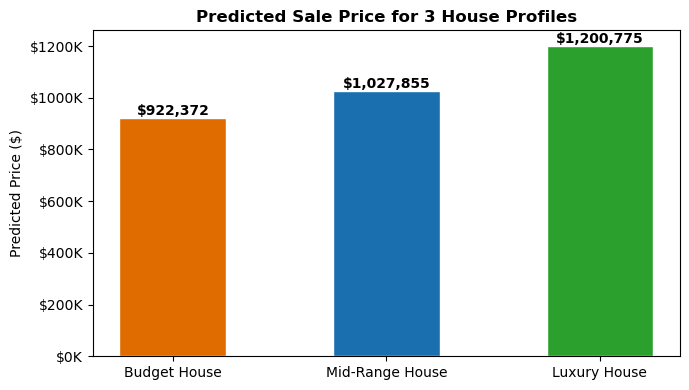

In [71]:
# Predict for 3 house profiles
house_profiles = pd.DataFrame(np.zeros((3, X.shape[1])), columns=X.columns)

# Budget house
house_profiles.loc[0, 'OverallQual']  = 4
house_profiles.loc[0, 'GrLivArea']    = 900
house_profiles.loc[0, 'GarageCars']   = 1
house_profiles.loc[0, 'TotalBsmtSF']  = 400
house_profiles.loc[0, 'YearBuilt']    = 1975
house_profiles.loc[0, 'FullBath']     = 1
house_profiles.loc[0, 'TotRmsAbvGrd'] = 5

# Mid-range house
house_profiles.loc[1, 'OverallQual']  = 7
house_profiles.loc[1, 'GrLivArea']    = 1800
house_profiles.loc[1, 'GarageCars']   = 2
house_profiles.loc[1, 'TotalBsmtSF']  = 900
house_profiles.loc[1, 'YearBuilt']    = 2000
house_profiles.loc[1, 'FullBath']     = 2
house_profiles.loc[1, 'TotRmsAbvGrd'] = 7

# Luxury house
house_profiles.loc[2, 'OverallQual']  = 10
house_profiles.loc[2, 'GrLivArea']    = 4000
house_profiles.loc[2, 'GarageCars']   = 3
house_profiles.loc[2, 'TotalBsmtSF']  = 2000
house_profiles.loc[2, 'YearBuilt']    = 2008
house_profiles.loc[2, 'FullBath']     = 3
house_profiles.loc[2, 'TotRmsAbvGrd'] = 10

prices = model.predict(house_profiles)
labels = ['Budget House', 'Mid-Range House', 'Luxury House']

print(f'{"Profile":<22} {"Predicted Price":>18}')
print('-' * 42)
for label, price in zip(labels, prices):
    print(f'{label:<22} ${price:>16,.0f}')


plt.figure(figsize=(7, 4))
bars = plt.bar(labels, prices,
               color=['#e06c00','#1a6faf','#2ca02c'], edgecolor='white', width=0.5)
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() * 1.01,
             f'${bar.get_height():,.0f}', ha='center', fontweight='bold', fontsize=10)
plt.title('Predicted Sale Price for 3 House Profiles',
          fontsize=12, fontweight='bold')
plt.ylabel('Predicted Price ($)')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'${x/1000:.0f}K'))
plt.tight_layout()
plt.show()

  Metric            Train Set         Test Set
--------------------------------------------------
  R² Score             0.9864           0.9749
  MSE         $    48,597,362  $    80,660,202
  RMSE        $         6,971  $         8,981

Very close scores — No overfitting!


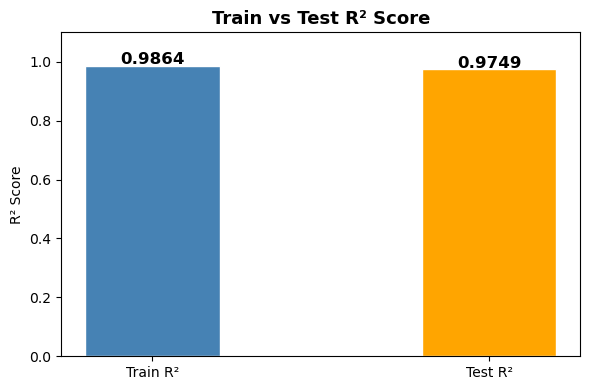

In [72]:
# Train vs Test Comparison (Overfitting Check)

y_train_pred = model.predict(X_train)

r2_train   = r2_score(y_train, y_train_pred)
r2_test_v  = r2_score(y_test,  y_pred)
mse_train  = mean_squared_error(y_train, y_train_pred)
mse_test_v = mean_squared_error(y_test,  y_pred)

print('=' * 50)
print(f'  {"Metric":<10}  {"Train Set":>15}  {"Test Set":>15}')
print('-' * 50)
print(f'  {"R² Score":<10}  {r2_train:>15.4f}  {r2_test_v:>15.4f}')
print(f'  {"MSE":<10}  ${mse_train:>14,.0f}  ${mse_test_v:>14,.0f}')
print(f'  {"RMSE":<10}  ${np.sqrt(mse_train):>14,.0f}  ${np.sqrt(mse_test_v):>14,.0f}')
print('=' * 50)

gap = abs(r2_train - r2_test_v)

if gap < 0.02:
    print('\nVery close scores — No overfitting!')
elif gap < 0.05:
    print('\nSmall gap — model generalizes well.')
else:
    print('\nNoticeable gap — slight overfitting. Consider regularization (Ridge/Lasso).')


plt.figure(figsize=(6, 4))
bars = plt.bar(['Train R²', 'Test R²'], [r2_train, r2_test_v],
               color=['steelblue','orange'], edgecolor='white', width=0.4)
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.005,
             f'{bar.get_height():.4f}', ha='center', fontweight='bold', fontsize=12)
plt.title('Train vs Test R² Score', fontsize=13, fontweight='bold')
plt.ylabel('R² Score')
plt.ylim(0, 1.1)
plt.tight_layout()
plt.show()

In [73]:
joblib.dump(model, 'house_price_model.pkl')

['house_price_model.pkl']

In [74]:
loaded_model = joblib.load('house_price_model.pkl')

In [75]:
test_pred = loaded_model.predict(new_house)[0]

## Key Findings:
    * OverallQual is the strongest predictor — quality of materials matters most
    * GrLivArea (above-ground living area) is the second most important feature
    * YearBuilt shows that newer houses command significantly higher prices
    * GarageCars and FullBath add meaningful value to the prediction
    * Data cleaning reduced 7,878 missing values to zero before modelling
    